In [1]:
import numpy as np
from jax import numpy as jnp
import jax
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, AnharmonicOscillator
from blueprint.devices import Device

import os, math

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update('jax_default_device', jax.devices('cuda')[1])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update('jax_enable_x64', False) # Simple
# dtype = jnp.complex64

# TODO:
- Get rid of caching (eigvals and eigkets)
- Fix time dependent term: support arg instead of kwarg
- Add Pauli Transfer Matrix construction
- Find the optimal or good enough free pulse params to do a good CZ
- Loss
- Metrics
- Make things run fine on cluster
- Add data type explicitely

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms, s = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi, 1e9 * 2 * math.pi

## Qubits

In [3]:
label = "Q1"
charging_energy = 0.24193246329355922 * GHz
josephson_energy = 16.861934403863096 * GHz
charge_cutoff = 100
offset_charge = 0.0
dim = 3

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    charge_cutoff=charge_cutoff,
)
transmon.diagonalize(dim)

label = "Q2"
charging_energy = 0.23958546598194805 * GHz
josephson_energy = 18.062900398155875 * GHz
charge_cutoff = 100
offset_charge = 0.0
dim = 3

other_transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    charge_cutoff=charge_cutoff,
)
other_transmon.diagonalize(dim)

In [4]:
print(transmon.get_hamiltonian())

[[ 0.          0.          0.        ]
 [ 0.          5.45922431  0.        ]
 [ 0.          0.         10.64760171]]


## Device

In [5]:
device = Device([transmon, other_transmon])
g0 = (
    7 * MHz
    / float(transmon.charge_zpf)
    / float(other_transmon.charge_zpf)
)
device.add_capacative_coupling(
    qubits=("Q1", "Q2"),
    label="C_Q1_Q2",
    prefactor=g0,
)
device.index_eigenstates()

In [6]:
print(device.get_hamiltonian())

[[-6.24089392e-34+0.j  1.10527194e-18+0.j -2.34787911e-34+0.j
  -3.95253473e-18+0.j  7.00000000e-03+0.j -1.48697828e-18+0.j
   1.49289360e-33+0.j -2.64393760e-18+0.j  5.61639684e-34+0.j]
 [ 1.10527194e-18+0.j  5.63337804e+00+0.j  1.52520159e-18+0.j
   7.00000000e-03+0.j  3.28474934e-18+0.j  9.65953331e-03+0.j
  -2.64393760e-18+0.j -1.24066747e-33+0.j -3.64845762e-18+0.j]
 [-2.09450433e-34+0.j  1.52520159e-18+0.j  1.09999300e+01+0.j
  -1.32650886e-18+0.j  9.65953331e-03+0.j -7.15406841e-20+0.j
   5.01029522e-34+0.j -3.64845762e-18+0.j  2.70213007e-35+0.j]
 [-3.95253473e-18+0.j  7.00000000e-03+0.j -1.48697828e-18+0.j
   5.45922431e+00+0.j  1.32278364e-17+0.j -2.80992935e-33+0.j
  -5.44762775e-18+0.j  9.64783280e-03+0.j -2.04944541e-18+0.j]
 [ 7.00000000e-03+0.j  3.28474934e-18+0.j  9.65953331e-03+0.j
   1.32278364e-17+0.j  1.10926024e+01+0.j  1.82535323e-17+0.j
   9.64783280e-03+0.j  4.52724464e-18+0.j  1.33133660e-02+0.j]
 [-1.32650886e-18+0.j  9.65953331e-03+0.j -7.15406841e-20+0.j
  -

In [7]:
print(device.get_int_hamiltonian()[jnp.abs(device.get_int_hamiltonian())>1e-8].real)

[0.007      0.007      0.00965953 0.00965953 0.007      0.00964783
 0.007      0.00965953 0.00964783 0.01331337 0.00965953 0.01331337
 0.00964783 0.00964783 0.01331337 0.01331337]


In [8]:
device.is_diagonalized

False

## Drives

### Flux drives

In [9]:
from blueprint.pulses import flux_pulses, coupler_pulses

In [10]:
device["Q1"].add_flux_drive(
    label='flux_Q1_cz_Q1_Q2', flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)
device["Q2"].add_flux_drive(
    label="flux_Q2_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)

In [11]:
0.8 / 0.255, 0.8 / 0.4163522432365655

(3.1372549019607843, 1.9214499573272414)

In [12]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843, #9.817191999999999,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

device["Q2"].drives["flux_Q2_cz_Q1_Q2"].set_params(
    hold_first_voltage=0.4163522432365655,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=1.9214499573272414, #9.90753,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

### Coupler drive v2

In [13]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.net_zero_transition_coupling_pulse
)

In [14]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    off_coupling=g0,
    on_coupling=g0 + 75 / np.sqrt(2) * MHz,
    # on_coupling=g0 + (9 / math.sqrt(2)) * MHz,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    gaussian_filter_sigma=0.5,
    transition_coupling=None,
)

## Function to build `Hfull: dq.TimeDependentArray` from a device  

In [15]:
import dynamiqs as dq
from jax import Array
from blueprint.base.terms import Numeric

/home/gene2902/blueprint-env/lib/python3.11/site-packages/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [16]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for qubit in device.qubits:
        drives_iterator = qubit.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )

    for coupling_label, coupling in device._couplings.items():
        drives_iterator = coupling.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            # print(prefactor.free_params)
            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )
    return dq_hamiltonian

In [17]:
full_hamiltonian = build_dynamiqs_hamiltonian(device=device)

0.0
0.0
0.0
0.0
0.0


In [18]:
full_hamiltonian(0.0)

Array([[-6.24089392e-34+0.j,  1.10527194e-18+0.j, -2.34787911e-34+0.j,
        -3.95253473e-18+0.j,  7.00000000e-03+0.j, -1.48697828e-18+0.j,
         1.49289360e-33+0.j, -2.64393760e-18+0.j,  5.61639684e-34+0.j],
       [ 1.10527194e-18+0.j,  5.63337804e+00+0.j,  1.52520159e-18+0.j,
         7.00000000e-03+0.j,  3.28474934e-18+0.j,  9.65953331e-03+0.j,
        -2.64393760e-18+0.j, -1.24066747e-33+0.j, -3.64845762e-18+0.j],
       [-2.09450433e-34+0.j,  1.52520159e-18+0.j,  1.09999300e+01+0.j,
        -1.32650886e-18+0.j,  9.65953331e-03+0.j, -7.15406841e-20+0.j,
         5.01029522e-34+0.j, -3.64845762e-18+0.j,  2.70213007e-35+0.j],
       [-3.95253473e-18+0.j,  7.00000000e-03+0.j, -1.48697828e-18+0.j,
         5.45922431e+00+0.j,  1.32278364e-17+0.j, -2.80992935e-33+0.j,
        -5.44762775e-18+0.j,  9.64783280e-03+0.j, -2.04944541e-18+0.j],
       [ 7.00000000e-03+0.j,  3.28474934e-18+0.j,  9.65953331e-03+0.j,
         1.32278364e-17+0.j,  1.10926024e+01+0.j,  1.82535323e-17+0.j,
  

In [19]:
full_hamiltonian(t=20.0).shape

(9, 9)

In [20]:
jnp.allclose(full_hamiltonian(0.0), device.get_hamiltonian())

Array(True, dtype=bool)

In [21]:
import qutip

In [22]:
qutip.Qobj(np.array(full_hamiltonian(0.0)))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[-6.24089392e-34  1.10527194e-18 -2.34787911e-34 -3.95253473e-18
   7.00000000e-03 -1.48697828e-18  1.49289360e-33 -2.64393760e-18
   5.61639684e-34]
 [ 1.10527194e-18  5.63337804e+00  1.52520159e-18  7.00000000e-03
   3.28474934e-18  9.65953331e-03 -2.64393760e-18 -1.24066747e-33
  -3.64845762e-18]
 [-2.09450433e-34  1.52520159e-18  1.09999300e+01 -1.32650886e-18
   9.65953331e-03 -7.15406841e-20  5.01029522e-34 -3.64845762e-18
   2.70213007e-35]
 [-3.95253473e-18  7.00000000e-03 -1.48697828e-18  5.45922431e+00
   1.32278364e-17 -2.80992935e-33 -5.44762775e-18  9.64783280e-03
  -2.04944541e-18]
 [ 7.00000000e-03  3.28474934e-18  9.65953331e-03  1.32278364e-17
   1.10926024e+01  1.82535323e-17  9.64783280e-03  4.52724464e-18
   1.33133660e-02]
 [-1.32650886e-18  9.65953331e-03 -7.15406841e-20 -2.50669174e-33
   1.82535323e-17  1.64591543e+01 -1.82827653e-18  1.33133660e-02
  -9.86017941e-20]
 [ 1

# dynamiqs

In [23]:
import time

In [24]:
# === initial states
psi0 = jnp.stack([
    device.get_eigenstate(0, 0)[1][:, None], 
    device.get_eigenstate(0, 1)[1][:, None],
    device.get_eigenstate(1, 0)[1][:, None],
    device.get_eigenstate(1, 1)[1][:, None],
])
psi0.shape

(4, 9, 1)

In [25]:
# === tsave
tsave = jnp.linspace(0, 100, 101)

In [26]:
# === run mesolve
t0 = time.time()
result = dq.mesolve(
    full_hamiltonian,
    jump_ops=[jnp.zeros((device.dim, device.dim))],
    rho0=psi0,
    tsave=tsave,
    # exp_ops=[],
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=100000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result)

Sim took 2.86 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (4, 101, 9, 9) | 511.31 Kb
Infos    : avg. 1390.5 steps (1374.5 accepted, 16.0 rejected) | infos shape (4,)


In [27]:
result.states.shape

(4, 101, 9, 9)

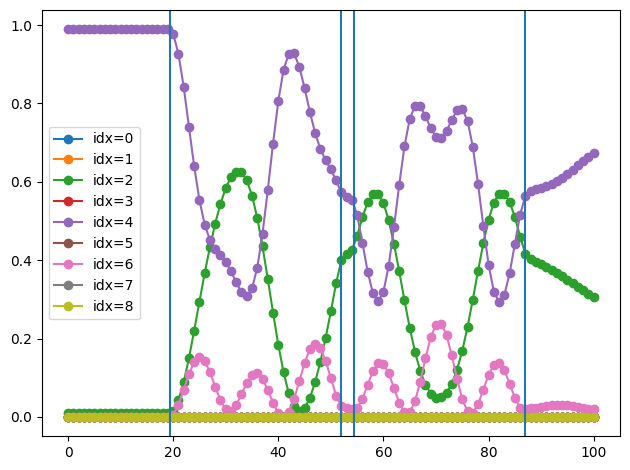

In [28]:
for idx in range(9):
    plt.plot(tsave, result.states[3, :, idx, idx].real, '-o', label=f'{idx=}')
plt.axvline(1.9349107142857144e1)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352)
plt.axvline(
    1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352 + 65.15 * 1 / 2
)
plt.legend()
plt.tight_layout()

In [29]:
device._eig_inds

Array([0, 2, 4, 1, 5, 7, 3, 6, 8], dtype=int64)

In [30]:
device.get_bare_hamiltonian().diagonal()

Array([ 0.        ,  5.63337804, 10.99993   ,  5.45922431, 11.09260236,
       16.45915431, 10.64760171, 16.28097976, 21.64753171], dtype=float64)

# Transition frequencies vs. external flux plots

In [35]:
# Do something dumb here because of the caching, will fix and improve later
ext_fluxes = np.linspace(0, math.pi, 101)

charge_cutoff = 100
offset_charge = 0.0
dim = 3

charging_energy_1 = 0.17874386390652913 * GHz
josephson_energy_1 = 28.045385714769342 * GHz
asymmetry_1 = 0.617379794210013

energies_0_t1 = np.zeros(ext_fluxes.shape)
energies_1_t1 = np.zeros(ext_fluxes.shape)
energies_2_t1 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_1 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_1,
        josephson_energy=josephson_energy_1,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        asymmetry=asymmetry_1,
        relax_time=None,
        deph_time=None,
    )
    transmon_1.diagonalize(dim)
    energies_0_t1[idx] = 0.0  # transmon_1.get_freq_difference(0, 1)
    energies_1_t1[idx] = transmon_1.get_freq_difference(0, 1)
    energies_2_t1[idx] = transmon_1.get_freq_difference(0, 2)

charging_energy_2 = 0.1706758643430758 * GHz
josephson_energy_2 = 27.770515104169455 * GHz
asymmetry_2 = 0.5487079408012716

energies_0_t2 = np.zeros(ext_fluxes.shape)
energies_1_t2 = np.zeros(ext_fluxes.shape)
energies_2_t2 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_2 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_2,
        josephson_energy=josephson_energy_2,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        asymmetry=asymmetry_2,
        relax_time=None,
        deph_time=None,
    )
    transmon_2.diagonalize(dim)
    energies_0_t2[idx] = 0.0  # transmon_1.get_freq_difference(0, 1)
    energies_1_t2[idx] = transmon_2.get_freq_difference(0, 1)
    energies_2_t2[idx] = transmon_2.get_freq_difference(0, 2)

In [36]:
transmon_1._asymm

0.617379794210013

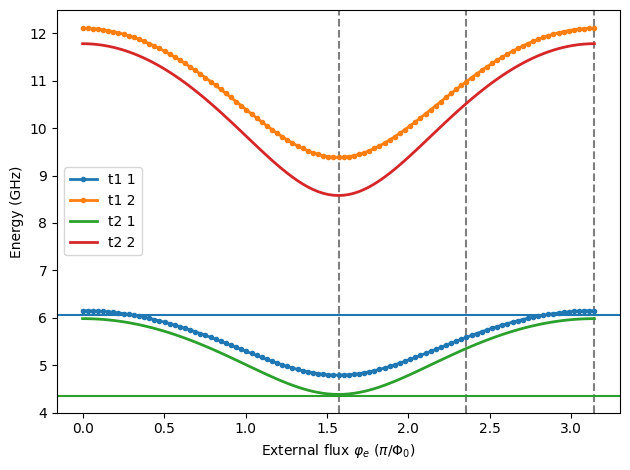

In [37]:
markers = ".-"
lw = 2.0
# plt.plot(ext_fluxes, energies_0_t1, markers, lw=lw, label=f"t1 0")
plt.plot(ext_fluxes, energies_1_t1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_2_t1, markers, lw=lw, label=f"t1 2")

markers = "-"
# plt.plot(ext_fluxes, energies_0_t2, markers, lw=lw, label=f"t2 0")
plt.plot(ext_fluxes, energies_1_t2, markers, lw=lw, label=f"t2 1")
plt.plot(ext_fluxes, energies_2_t2, markers, lw=lw, label=f"t2 2")

plt.axhline(6.067657949379383, ls="-", c="C0")
plt.axhline(4.344903495992916, ls="-", c="C2")

plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi * 3/4, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [38]:
effective_josephson_energies_1 = (
    josephson_energy_1 * abs(np.cos(ext_fluxes)) *
    np.sqrt(1 + asymmetry_1**2 * np.tan(ext_fluxes)**2)
)
frequencies_1 = (
    np.sqrt(8 * charging_energy_1 * abs(effective_josephson_energies_1))
    - charging_energy_1
)

effective_josephson_energies_2 = (
    josephson_energy_2
    * abs(np.cos(ext_fluxes))
    * np.sqrt(1 + asymmetry_2**2 * np.tan(ext_fluxes) ** 2)
)
frequencies_2 = (
    np.sqrt(8 * charging_energy_2 * abs(effective_josephson_energies_2))
    - charging_energy_2
)

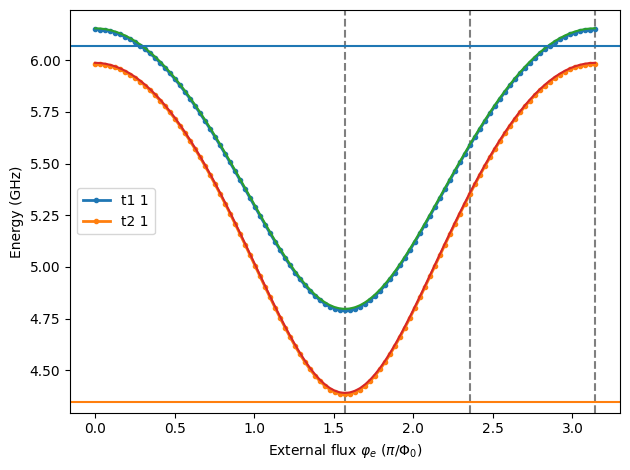

In [39]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_1_t1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_1_t2, markers, lw=lw, label=f"t2 1")

plt.plot(ext_fluxes, frequencies_1, "-")
plt.plot(ext_fluxes, frequencies_2, "-")

plt.axhline(6.067657949379383, ls="-", c="C0")
plt.axhline(4.344903495992916, ls="-", c="C1")

plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

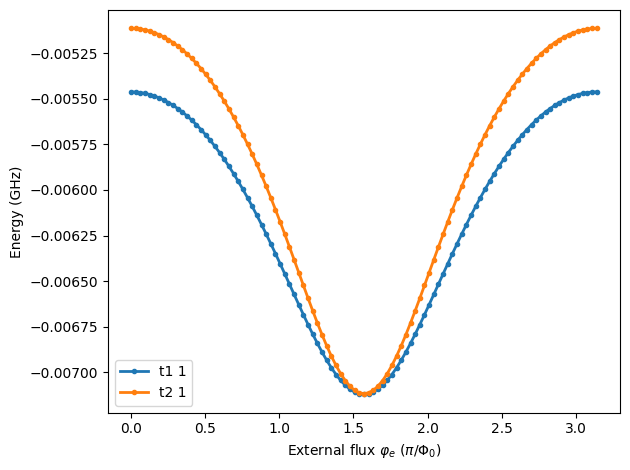

In [40]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_1_t1 - frequencies_1, markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, energies_1_t2 - frequencies_2, markers, lw=lw, label=f"t2 1")

# plt.plot(ext_fluxes, frequencies_1, "-")
# plt.plot(ext_fluxes, frequencies_2, "-")

# plt.axhline(6.067657949379383, ls="-", c="C0")
# plt.axhline(4.344903495992916, ls="-", c="C1")

plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [45]:
.27 * math.pi

0.8482300164692442

In [46]:
# Do something dumb here because of the caching, will fix and improve later
ext_fluxes = np.linspace(0.23 * math.pi, 0.27 * math.pi, 101)

charge_cutoff = 100
offset_charge = 0.0
dim = 3

charging_energy_1 = 0.17874386390652913 * GHz
josephson_energy_1 = 28.045385714769342 * GHz
asymmetry_1 = 0.617379794210013

charging_energy_2 = 0.1706758643430758 * GHz
josephson_energy_2 = 27.770515104169455 * GHz
asymmetry_2 = 0.5487079408012716

energies_00 = np.zeros(ext_fluxes.shape)
energies_01 = np.zeros(ext_fluxes.shape)
energies_02 = np.zeros(ext_fluxes.shape)
energies_10 = np.zeros(ext_fluxes.shape)
energies_11 = np.zeros(ext_fluxes.shape)
energies_12 = np.zeros(ext_fluxes.shape)
energies_20 = np.zeros(ext_fluxes.shape)
energies_21 = np.zeros(ext_fluxes.shape)
energies_22 = np.zeros(ext_fluxes.shape)

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_1 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy_1,
        josephson_energy=josephson_energy_1,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        # ext_flux=0.0,
        asymmetry=asymmetry_1,
        relax_time=None,
        deph_time=None,
    )
    transmon_1.diagonalize(dim)
    transmon_2 = TunableTransmon(
        label="Q2",
        charging_energy=charging_energy_2,
        josephson_energy=josephson_energy_2,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        # ext_flux=math.pi / 2,
        ext_flux=ext_flux + math.pi / 2,
        asymmetry=asymmetry_2,
        relax_time=None,
        deph_time=None,
    )
    transmon_2.diagonalize(dim)
    device = Device([transmon_1, transmon_2])
    g0 = 7 * MHz / float(transmon_1.charge_zpf) / float(transmon_2.charge_zpf)
    device.add_capacative_coupling(
        qubits=("Q1", "Q2"),
        label="C_Q1_Q2",
        prefactor=g0,
    )
    device.index_eigenstates()
    energies_00[idx] = device.get_eigenstate(0, 0)[0]
    energies_01[idx] = device.get_eigenstate(0, 1)[0]
    energies_02[idx] = device.get_eigenstate(0, 2)[0]
    energies_10[idx] = device.get_eigenstate(1, 0)[0]
    energies_11[idx] = device.get_eigenstate(1, 1)[0]
    energies_12[idx] = device.get_eigenstate(1, 2)[0]
    energies_20[idx] = device.get_eigenstate(2, 0)[0]
    energies_21[idx] = device.get_eigenstate(2, 1)[0]
    energies_22[idx] = device.get_eigenstate(2, 2)[0]

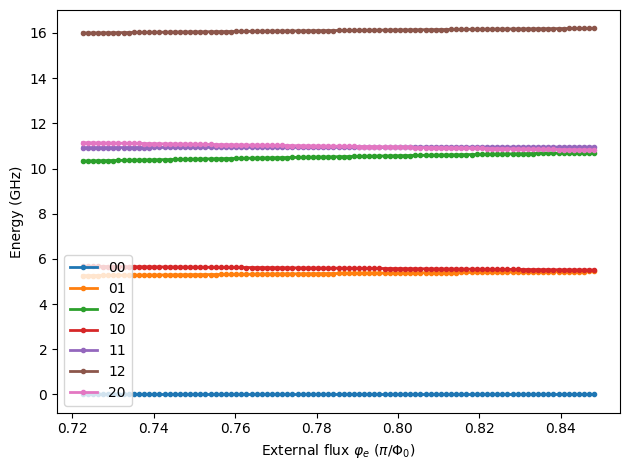

In [48]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

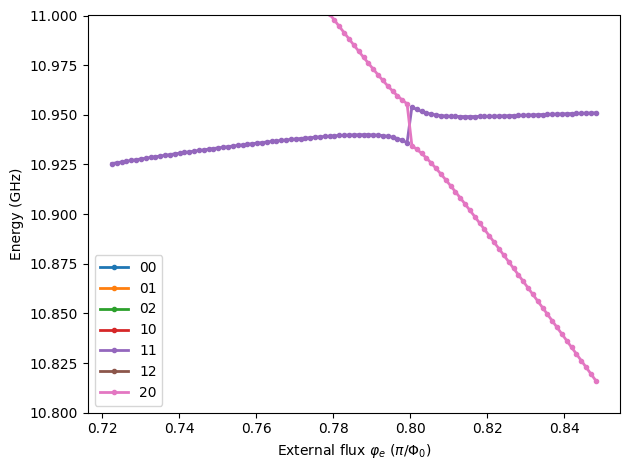

In [51]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
# plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.ylim([10.8, 11])
plt.tight_layout()

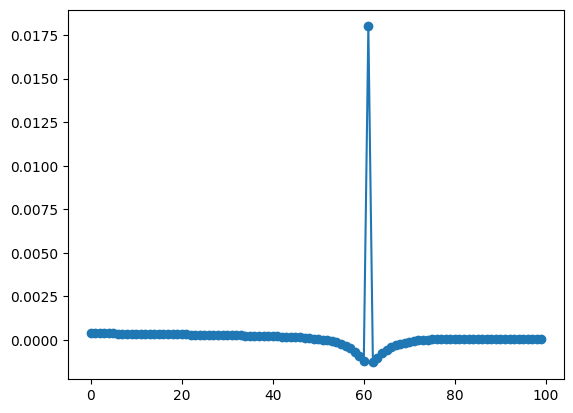

In [53]:
plt.plot(np.diff(energies_11), '-o')

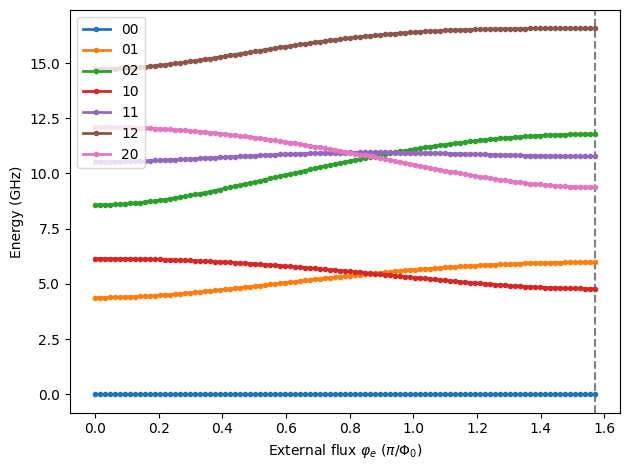

In [42]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [43]:
transmon_1.abs_anharmonicity

Array(-0.19614596, dtype=float64)

In [ ]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.ylim([10.5, 11.2])
plt.tight_layout()

In [ ]:
markers = ".-"
lw = 2.0
# plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
# plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes,np.abs(energies_11 - energies_02), markers, lw=lw, label=f"02")
# plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
# plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
# plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, np.abs(energies_11 - energies_20), markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.axhline(-2 * transmon_1.abs_anharmonicity)
# plt.ylim([10.5, 11.2])
plt.tight_layout()

In [ ]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [ ]:
markers = ".-"
lw = 2.
plt.plot(ext_fluxes, energies_00, markers, lw=lw, label=f"00")
plt.plot(ext_fluxes, energies_01, markers, lw=lw, label=f"01")
plt.plot(ext_fluxes, energies_02, markers, lw=lw, label=f"02")
plt.plot(ext_fluxes, energies_10, markers, lw=lw, label=f"10")
plt.plot(ext_fluxes, energies_11, markers, lw=lw, label=f"11")
plt.plot(ext_fluxes, energies_12, markers, lw=lw, label=f"12")
plt.plot(ext_fluxes, energies_20, markers, lw=lw, label=f"20")
# plt.plot(ext_fluxes, energies_21, markers, lw=lw, label=f"21")
# plt.plot(ext_fluxes, energies_22, markers, lw=lw, label=f"22")
plt.legend()
plt.axvline(math.pi / 2, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi * 3 / 4, ls="--", c="tab:gray", zorder=-1)
# plt.axvline(math.pi, ls="--", c="tab:gray", zorder=-1)
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [ ]:
energies_00

In [ ]:
170675864.3430758 / 1e9

In [ ]:
device.get_eigenstate(0, 0)

# Drive plots

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
drives_list[0]

# OLD Coupler drive
Where we use the frequencies of both qubits at time t (getting the flux from NZT callables and approximating the freq from ext_flux) and the first-order perturbation theory expression for g(delta_1c, delta_2c)

In [ ]:
# device._couplings["C_Q1_Q2"].add_drive(
#     label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.capacitive_coupling_pulse
# )

In [ ]:
from typing import Callable
from functools import partial
from blueprint.base import QuantumSystem
from blueprint.qubits import TunableTransmon


def build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1: TunableTransmon,
    transmon_2: TunableTransmon,
    flux_drive_label_1: str,
    flux_drive_label_2: str,
    flux_callable_1: Callable = flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2: Callable = flux_pulses.net_zero_transition_flux_pulse,
):
    # Only use the params that are set (i.e. not None) in the Drive object.
    flux_drive_1 = transmon_1.drives[flux_drive_label_1]
    not_none_params_1 = {
        key: val for key, val in flux_drive_1.param_vals.items() if val is not None
    }
    partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)
    # Same for transmon 2
    flux_drive_2 = transmon_2.drives[flux_drive_label_2]
    not_none_params_2 = {
        key: val for key, val in flux_drive_2.param_vals.items() if val is not None
    }
    partial_func_flux_2 = partial(flux_callable_2, **not_none_params_2)

    return partial(
        coupler_pulses.capacitive_coupling_pulse,
        flux_drive_transmon_1=partial_func_flux_1,
        flux_drive_transmon_2=partial_func_flux_2,
        EJ_1=transmon_1._ej,
        EJ_2=transmon_2._ej,
        EC_1=transmon_1._ec,
        EC_2=transmon_2._ec,
        asymm_1=transmon_1._asymm,
        asymm_2=transmon_2._asymm,
        static_ext_flux_1=transmon_1._ext_flux,
        static_ext_flux_2=transmon_2._ext_flux,
    )

In [ ]:
# Only use the params that are set (i.e. not None) in the Drive object.
transmon_1 = device["Q1"]
flux_drive_label_1 = "flux_Q1_cz_Q1_Q2"
flux_callable_1 = flux_pulses.net_zero_transition_flux_pulse

flux_drive_1 = transmon_1.drives[flux_drive_label_1]
not_none_params_1 = {
    key: val for key, val in flux_drive_1.param_vals.items() if val is not None
}
partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)

In [ ]:
partial_func_flux_1(0.0)

In [ ]:
print(transmon._ext_flux)
print(other_transmon._ext_flux)

In [ ]:
coupler_pulse = build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1=device["Q1"],
    transmon_2=device["Q2"],
    flux_drive_label_1="flux_Q1_cz_Q1_Q2",
    flux_drive_label_2="flux_Q2_cz_Q1_Q2",
    flux_callable_1=flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2=flux_pulses.net_zero_transition_flux_pulse,
)

In [ ]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulse
)

In [ ]:
g0 = 7 * MHz / float(transmon.charge_zpf) / float(other_transmon.charge_zpf)
g0

In [ ]:
frequency_resonator=10.0 * GHz
omega_q1 = device["Q1"].fundamental_frequency
omega_q2 = device["Q2"].fundamental_frequency
delta_1 = abs(omega_q1 - frequency_resonator)
delta_2 = abs(omega_q2 - frequency_resonator)
coupling_to_res = math.sqrt(2 * g0 * delta_1 * delta_2 / (delta_1 + delta_2))
coupling_to_res

In [ ]:
coupling_to_res**2 / 2 * (1 / delta_1 + 1 / delta_2)

In [ ]:
g0

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    frequency_resonator=frequency_resonator,
    coupling_res_trans_1=coupling_to_res,
    coupling_res_trans_2=coupling_to_res,
)

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].eval_prefactors(t=0.0)

In [ ]:
for prefactor, operator in device._couplings["C_Q1_Q2"].get_drive_hamiltonian(
    decompose=True
):
    print(prefactor(t=0.0))
    print(operator)

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
device.get_int_hamiltonian()

In [ ]:
device["Q1"].fundamental_frequency

In [ ]:
def compute_freq(ext_flux, asymm, EJ, EC):
    # Do the `compute_eff_josephson_energy()` part
    cos_term = math.cos(ext_flux)
    sqrt_term = math.sqrt(1 + asymm**2 * math.tan(ext_flux) ** 2)
    EJ_effective_1 = EJ * abs(cos_term) * sqrt_term
    # Do the `ext_flux_to_approx_freq()` part
    frequency = math.sqrt(8 * EC * EJ_effective_1) - EC
    return frequency

compute_freq(
    device["Q1"]._ext_flux, device["Q1"]._asymm, device["Q1"]._ej, device["Q1"]._ec)